In [2]:
import numpy as np
from sympy.physics.wigner import wigner_9j
from sympy import sqrt, N, Rational
from fractions import Fraction
import math
import sympy
from sympy.physics.wigner import wigner_6j

## Transformation from LS coupling to JJ Coupling
### Identical Two electron configuration

In [3]:


def calculate_ls_jj_matrix_equivalent(l, s, J,output=True):
    """
    Calculate the LS to jj coupling transformation matrix for a given J value.
    Applicable to: equivalent electron configurations l² 
    """
    # 1. Define possible LS states (following Pauli exclusion principle: L+S must be even)
    ls_states = []
    # Iterate over possible S (0, 1) and L (0, 1, 2)
    for S in [0, 1]:
        for L in range(abs(l - l), l + l + 1):
            # Pauli principle filter
            if (L + S) % 2 == 0:
                # Triangle inequality filter: |L-S| <= J <= L+S
                if abs(L - S) <= J <= L + S:
                    term_symbol = f"^{2*S+1}{'SPDFGH'[L]}_{J}"
                    ls_states.append({'S': S, 'L': L, 'label': term_symbol})

    # 2. Define possible jj states
    jj_states = []
    j_values = [Rational(1, 2), Rational(3, 2)]  # For p orbitals: 1/2, 3/2 as fractions
    
    # Iterate over all possible (j1, j2) combinations (keep j1 <= j2 to avoid duplication)
    for i, j1 in enumerate(j_values):
        for j2 in j_values[i:]:
            # Triangle inequality filter: |j1-j2| <= J <= j1+j2
            if abs(j1 - j2) <= J <= j1 + j2:
                # Pauli principle filter: If j1 == j2, J must be even
                if j1 == j2 and J % 2 != 0:
                    continue
                
                label = f"({j1},{j2})_{J}"
                jj_states.append({'j1': j1, 'j2': j2, 'label': label})

    # 3. Build transformation matrix
    # Matrix elements M_ij = <LS_i | jj_j>
    matrix = np.zeros((len(ls_states), len(jj_states)))

    for r, ls in enumerate(ls_states):
        for c, jj in enumerate(jj_states):
            S, L = ls['S'], ls['L']
            j1, j2 = jj['j1'], jj['j2']
            
            # --- Core formula calculation ---
            prefactor = sqrt((2*S + 1) * (2*L + 1) * (2*j1 + 1) * (2*j2 + 1))
            nine_j = wigner_9j(l, l, L, s, s, S, j1, j2, J)
            val = prefactor * nine_j
            
            # --- Equivalent electron correction ---
            if j1 != j2:
                val *= sqrt(2)
            
            matrix[r, c] = float(val)

    if output==True:

        print(f"\nCalculating transformation matrix for J = {J}:")
        print(f"{'LS States':<10} | {'jj States'}")
        print("-" * 60)
        
        # Print header
        header = " " * 10
        for state in jj_states:
            header += f"{state['label']:>15}"
        print(header)

        for r, ls in enumerate(ls_states):
            row_str = f"{ls['label']:<10}"
            for c, jj in enumerate(jj_states):
                # Use already calculated matrix values
                row_str += f"{matrix[r, c]:15.4f}"
            print(row_str)
        
    return ls_states, jj_states, matrix                

In [4]:
# --- Main program: Calculate Sn 5p² ---
print("Lead (Sn) 5p² Configuration Transformation (LS -> jj)")
print("======================================================")

# Physical parameters: p orbital (l=1), electron spin (s=1/2)
l_val = 1
s_val = Rational(1, 2)  # Use fraction for spin

# Calculate for J=0, 1, 2 cases separately
for J_val in [0, 1, 2]:
    calculate_ls_jj_matrix_equivalent(l_val, s_val, J_val)

Lead (Sn) 5p² Configuration Transformation (LS -> jj)

Calculating transformation matrix for J = 0:
LS States  | jj States
------------------------------------------------------------
              (1/2,1/2)_0    (3/2,3/2)_0
^1S_0              0.5774         0.8165
^3P_0              0.8165        -0.5774

Calculating transformation matrix for J = 1:
LS States  | jj States
------------------------------------------------------------
              (1/2,3/2)_1
^3P_1              1.0000

Calculating transformation matrix for J = 2:
LS States  | jj States
------------------------------------------------------------
              (1/2,3/2)_2    (3/2,3/2)_2
^1D_2             -0.8165         0.5774
^3P_2              0.5774         0.8165


### Non-equivalent Two electron

In [5]:
import numpy as np
from sympy.physics.wigner import wigner_9j
from sympy import sqrt, Rational
from fractions import Fraction

def calculate_ls_jj_nonequivalent(l1, l2, s, J, output=True):
    """
    Calculate the LS to jj coupling transformation matrix for non-equivalent electrons.
    Example: Pb 6p 7s (l1=1, l2=0)
    """
    # 1. Define possible LS states
    ls_states = []
    # Iterate over possible S (0, 1)
    for S in [0, 1]:
        # Iterate over possible L (|l1-l2| to l1+l2)
        for L in range(abs(l1 - l2), l1 + l2 + 1):
            # Only constraint: triangle inequality |L-S| <= J <= L+S
            # Note: No (L+S)%2 Pauli exclusion check needed here
            if abs(L - S) <= J <= L + S:
                term_label = "S" if S==0 else "T" # Singlet/Triplet
                orb_label = "SPDFGH"[L]
                label = f"^{2*S+1}{orb_label}_{J}"
                ls_states.append({'S': S, 'L': L, 'l1': l1, 'l2': l2, 'label': label})

    # 2. Define possible jj states
    # j values for electron 1 (as fractions)
    j1_values = [Rational(l1 - s), Rational(l1 + s)] if l1 > 0 else [Rational(s)]
    # j values for electron 2 (as fractions)
    j2_values = [Rational(l2 - s), Rational(l2 + s)] if l2 > 0 else [Rational(s)]
    
    jj_states = []
    for j1 in j1_values:
        for j2 in j2_values:
            # Only constraint: triangle inequality |j1-j2| <= J <= j1+j2
            if abs(j1 - j2) <= J <= j1 + j2:
                label = f"({j1},{j2})_{J}"
                jj_states.append({'j1': j1, 'j2': j2, 'label': label})

    # 3. Build transformation matrix
    if not ls_states or not jj_states:
        return # No states for this J value

    matrix = np.zeros((len(ls_states), len(jj_states)))

    for r, ls in enumerate(ls_states):
        for c, jj in enumerate(jj_states):
            S, L = ls['S'], ls['L']
            j1, j2 = jj['j1'], jj['j2']
            
            # --- Core formula (Eq. 5.227) ---
            prefactor = sqrt((2*S + 1) * (2*L + 1) * (2*j1 + 1) * (2*j2 + 1))
            nine_j = wigner_9j(l1, l2, L, s, s, S, j1, j2, J)
            val = prefactor * nine_j
            matrix[r, c] = float(val)

    if output == True:
        print(f"\nCalculating transformation matrix for J = {J} (non-equivalent):")
        print(f"{'LS States':<10} | {'jj States'}")
        print("-" * 45)
    
        header = " " * 10
        for state in jj_states:
            header += f"{state['label']:>15}"
        print(header)

        for r, ls in enumerate(ls_states):
            row_str = f"{ls['label']:<10}"
            for c, jj in enumerate(jj_states):
                S, L = ls['S'], ls['L']
                j1, j2 = jj['j1'], jj['j2']
                
                # --- Core formula (Eq. 5.227) ---
                # sqrt((2S+1)(2L+1)(2j1+1)(2j2+1))
                prefactor = sqrt((2*S + 1) * (2*L + 1) * (2*j1 + 1) * (2*j2 + 1))
                
                # Wigner 9j symbol
                # { l1  l2  L }
                # { s   s   S }
                # { j1  j2  J }

                nine_j = wigner_9j(l1, l2, L, s, s, S, j1, j2, J)
                val = prefactor * nine_j
                
                # Note: No sqrt(2) correction needed for non-equivalent electrons!
                row_str += f"{float(val):15.4f}"
            print(row_str)
    
    return ls_states, jj_states, matrix
                

### Convert LS Coupling to JJ Coulping in eigenstate

From the sobleman textbook, he gave a example of p^2. He show the calculation of the eigenstate in LS Coupling scheme.
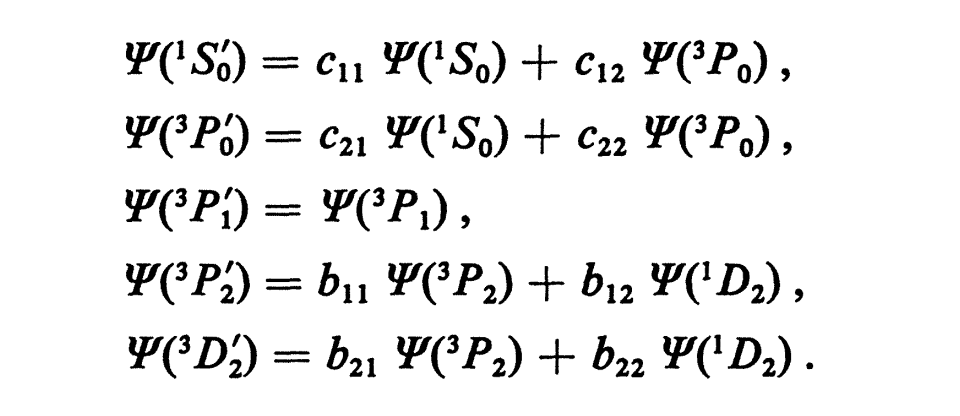
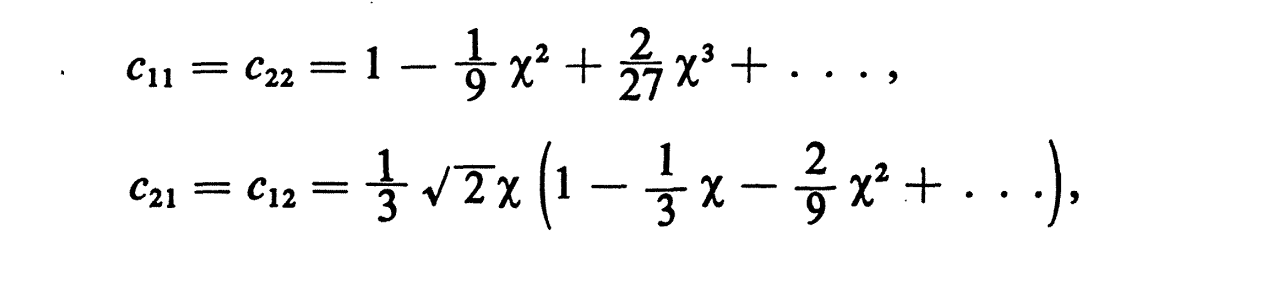
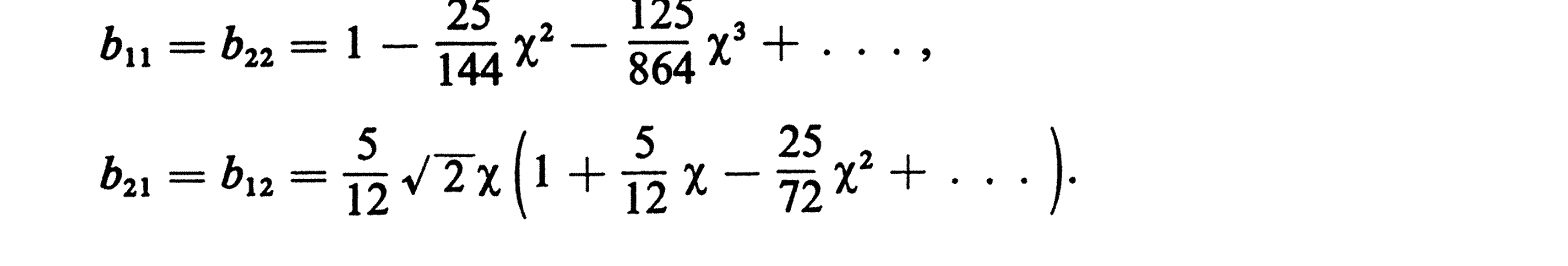

In [6]:
### Calculate Cofficient

def coeffs_from_chi(chi):
    """
    Compute the mixing coefficients c_ij as series in chi.

    Formulas (truncated to the terms shown in the book):
        c11 = c22 = 1 - 1/9 * chi**2 + 2/27 * chi**3 + ...
        c21 = c12 = (1/3)*sqrt(2)*chi * (1 - 1/3*chi - 2/9*chi**2 + ...)

    Parameters
    ----------
    chi : float
        The small parameter χ.

    Returns
    -------
    dict
        Dictionary with c11, c22, c21, c12.
    """

    # c11 and c22
    c11 = 1.0 - (1.0/9.0)*chi**2 + (2.0/27.0)*chi**3
    c22 = c11

    # c21 and c12
    prefactor = (1.0/3.0) * math.sqrt(2.0) * chi
    inner = 1.0 - (1.0/3.0)*chi - (2.0/9.0)*chi**2
    c21 = prefactor * inner
    c12 = c21

    return {"c11": c11, "c22": c22, "c21": c21, "c12": c12}

def b_coeffs_from_chi(chi):
    """
    Compute the mixing coefficients b_ij as series in chi.

    Formulas (truncated to the terms shown):
        b11 = b22 = 1 - 25/144 * chi^2 - 125/864 * chi^3 + ...
        b21 = b12 = (5/12)*sqrt(2)*chi * (1 + 5/12*chi - 25/72*chi^2 + ...)

    Parameters
    ----------
    chi : float
        Small parameter χ.

    Returns
    -------
    dict
        Dictionary with b11, b22, b21, b12.
    """

    # b11 and b22
    b11 = 1.0 - (25.0/144.0)*chi**2 - (125.0/864.0)*chi**3
    b22 = b11

    # b21 and b12
    prefactor = (5.0/12.0) * math.sqrt(2.0) * chi
    inner = 1.0 + (5.0/12.0)*chi - (25.0/72.0)*chi**2
    b21 = prefactor * inner
    b12 = b21

    return {"b11": b11, "b22": b22, "b21": b21, "b12": b12}



In [7]:

chi = 0.467139
cs = coeffs_from_chi(chi)
bs = b_coeffs_from_chi(chi)
print(f"chi = {chi}")
for name, val in bs.items():
    print(f"{name} = {val:.8f}")
    
norm1 = bs["b11"]**2 + bs["b21"]**2
norm2 = bs["b22"]**2 + bs["b12"]**2
print("norm1 =", norm1)
print("norm2 =", norm2)
    
print(f"chi = {chi}")
for name, val in cs.items():
    print(f"{name} = {val:.8f}")


norm1 = cs["c11"]**2 + cs["c21"]**2
norm2 = cs["c22"]**2 + cs["c12"]**2
print("norm1 =", norm1)
print("norm2 =", norm2)

chi = 0.467139
b11 = 0.94736673
b22 = 0.94736673
b21 = 0.30798519
b12 = 0.30798519
norm1 = 0.9923586007989239
norm2 = 0.9923586007989239
chi = 0.467139
c11 = 0.98330446
c22 = 0.98330446
c21 = 0.17524292
c12 = 0.17524292
norm1 = 0.9975977511416196
norm2 = 0.9975977511416196


In [8]:
def convert_ls_to_jj_eigenstate(ls_coefficients, J_val, l=1, s=Rational(1,2), is_equivalent=True):
    """
    Convert an eigenstate from LS coupling to jj coupling representation.
    
    Parameters:
    -----------
    ls_coefficients : dict
        Dictionary with LS state labels as keys and coefficients as values
        Example: {'^1S_0': 0.8, '^3P_0': 0.6}
    J_val : int
        Total angular momentum quantum number
    l : int
        Orbital angular momentum quantum number (default: 1 for p orbitals)
    s : Rational
        Spin quantum number (default: 1/2)
    is_equivalent : bool
        True for equivalent electrons (like p²), False for non-equivalent (like ps)
    
    Returns:
    --------
    dict
        Dictionary with jj state labels as keys and coefficients as values
    """
    
    # Get transformation matrix and state labels
    if is_equivalent:
        ls_states, jj_states, transform_matrix = calculate_ls_jj_matrix_equivalent(l, s, J_val, output=False)
    else:
        # For non-equivalent electrons, use l1=1 (p), l2=0 (s)
        ls_states, jj_states, transform_matrix = calculate_ls_jj_nonequivalent(1, 0, s, J_val, output=False)
        if ls_states is None or jj_states is None:
            return {}
    
    # Create mapping from LS labels to indices
    ls_label_to_index = {state['label']: i for i, state in enumerate(ls_states)}
    
    # Initialize jj coefficients
    jj_coefficients = {}
    for state in jj_states:
        jj_coefficients[state['label']] = 0.0
    
    # Transform coefficients: |jj⟩ = Σ T_ji |LS_i⟩
    # So c_jj = Σ T_ji * c_LS_i
    for ls_label, ls_coeff in ls_coefficients.items():
        if ls_label in ls_label_to_index:
            ls_idx = ls_label_to_index[ls_label]
            
            # Add contribution to each jj state
            for jj_idx, jj_state in enumerate(jj_states):
                jj_label = jj_state['label']
                transform_element = transform_matrix[ls_idx, jj_idx]
                jj_coefficients[jj_label] += transform_element * ls_coeff
    
    # Remove zero coefficients for cleaner output
    jj_coefficients = {k: v for k, v in jj_coefficients.items() if abs(v) > 1e-10}
    
    return jj_coefficients

def print_eigenstate_conversion(ls_coeffs, J_val, state_name="", is_equivalent=True, verbose=True):
    """
    Convert and optionally print the conversion of an eigenstate from LS to jj coupling.
    
    Parameters:
    -----------
    ls_coeffs : dict
        LS coupling coefficients
    J_val : int
        Total angular momentum quantum number
    state_name : str
        Name of the state for display purposes
    is_equivalent : bool
        True for equivalent electrons, False for non-equivalent
    verbose : bool
        If True, print detailed conversion information. If False, only return coefficients.
    
    Returns:
    --------
    dict
        jj coupling coefficients
    """
    
    # Convert to jj coupling
    jj_coeffs = convert_ls_to_jj_eigenstate(ls_coeffs, J_val, is_equivalent=is_equivalent)
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"Converting {state_name} eigenstate from LS to jj coupling (J={J_val})")
        print(f"{'='*60}")
        
        print(f"\nOriginal LS coupling representation:")
        for ls_label, coeff in ls_coeffs.items():
            print(f"  {coeff:8.4f} |{ls_label}⟩")
        
        print(f"\nCorresponding jj coupling representation:")
        if jj_coeffs:
            for jj_label, coeff in jj_coeffs.items():
                print(f"  {coeff:8.4f} |{jj_label}⟩")
        else:
            print("  No valid jj states for this J value")
        
        # Verify normalization
        norm_ls = sum(c**2 for c in ls_coeffs.values())
        norm_jj = sum(c**2 for c in jj_coeffs.values())
        print(f"\nNormalization check:")
        print(f"  LS norm²  = {norm_ls:.6f}")
        print(f"  jj norm² = {norm_jj:.6f}")
    
    return jj_coeffs


In [9]:
# Calculation based on the complete mixing formulas
print("="*80)
print("COMPLETE EIGENSTATE ANALYSIS WITH MIXING")
print("="*80)

# Parameters
chi = 0.467139
cs = coeffs_from_chi(chi)
bs = b_coeffs_from_chi(chi)

print(f"Using chi = {chi}")
print(f"c-coefficients: c11={cs['c11']:.6f}, c12={cs['c12']:.6f}, c21={cs['c21']:.6f}, c22={cs['c22']:.6f}")
print(f"b-coefficients: b11={bs['b11']:.6f}, b12={bs['b12']:.6f}, b21={bs['b21']:.6f}, b22={bs['b22']:.6f}")

print("\n" + "="*60)
print("MIXED EIGENSTATES ACCORDING TO YOUR FORMULAS:")
print("="*60)

# Define all mixed eigenstates according to your formulas
eigenstates = {
    # J=0 states
    "Ψ(¹S₀')": {
        "J": 0,
        "coeffs": {'^1S_0': cs['c11'], '^3P_0': cs['c12']},
        "formula": "c₁₁Ψ(¹S₀) + c₁₂Ψ(³P₀)"
    },
    "Ψ(³P₀')": {
        "J": 0, 
        "coeffs": {'^1S_0': cs['c21'], '^3P_0': cs['c22']},
        "formula": "c₂₁Ψ(¹S₀) + c₂₂Ψ(³P₀)"
    },
    
    # J=1 state (no mixing)
    "Ψ(³P₁')": {
        "J": 1,
        "coeffs": {'^3P_1': 1.0},
        "formula": "Ψ(³P₁)"
    },
    
    # J=2 states with mixing
    "Ψ(³P₂')": {
        "J": 2,
        "coeffs": {'^3P_2': bs['b11'], '^1D_2': bs['b12']},
        "formula": "b₁₁Ψ(³P₂) + b₁₂Ψ(¹D₂)"
    },
    "Ψ(¹D₂')": {
        "J": 2,
        "coeffs": {'^3P_2': bs['b21'], '^1D_2': bs['b22']},
        "formula": "b₂₁Ψ(³P₂) + b₂₂Ψ(¹D₂)"
    }
}

# Calculate jj coupling for each eigenstate
print(f"\nDetailed calculations:")
print("-" * 60)

all_jj_results = {}

for state_name, state_info in eigenstates.items():
    J_val = state_info["J"]
    coeffs = state_info["coeffs"]
    formula = state_info["formula"]
    
    print(f"\n{state_name}:")
    print(f"  Formula: {formula}")
    
    # Show LS representation
    ls_str = " + ".join([f"{coeff:.4f}|{label}⟩" for label, coeff in coeffs.items()])
    print(f"  LS:      {ls_str}")
    
    # Convert to jj coupling
    jj_coeffs = print_eigenstate_conversion(
        coeffs, 
        J_val, 
        state_name=state_name, 
        is_equivalent=True, 
        verbose=False
    )
    
    # Store results
    all_jj_results[state_name] = jj_coeffs
    
    # Show jj representation
    if jj_coeffs:
        jj_str = " + ".join([f"{coeff:.4f}|{label}⟩" for label, coeff in jj_coeffs.items()])
        print(f"  jj:      {jj_str}")
        
        # Check normalization
        norm_ls = sum(c**2 for c in coeffs.values())
        norm_jj = sum(c**2 for c in jj_coeffs.values())
        print(f"  Norm:    LS={norm_ls:.6f}, jj={norm_jj:.6f}")
    else:
        print(f"  jj:      No valid states")

# Summary table of all results
print("\n" + "="*80)
print("SUMMARY: ALL MIXED EIGENSTATES IN JJ COUPLING")
print("="*80)

for state_name, jj_coeffs in all_jj_results.items():
    print(f"\n{state_name}:")
    if jj_coeffs:
        for jj_label, coeff in jj_coeffs.items():
            print(f"    {coeff:8.5f} × |{jj_label}⟩")
    else:
        print("    No valid jj states")


COMPLETE EIGENSTATE ANALYSIS WITH MIXING
Using chi = 0.467139
c-coefficients: c11=0.983304, c12=0.175243, c21=0.175243, c22=0.983304
b-coefficients: b11=0.947367, b12=0.307985, b21=0.307985, b22=0.947367

MIXED EIGENSTATES ACCORDING TO YOUR FORMULAS:

Detailed calculations:
------------------------------------------------------------

Ψ(¹S₀'):
  Formula: c₁₁Ψ(¹S₀) + c₁₂Ψ(³P₀)
  LS:      0.9833|^1S_0⟩ + 0.1752|^3P_0⟩
  jj:      0.7108|(1/2,1/2)_0⟩ + 0.7017|(3/2,3/2)_0⟩
  Norm:    LS=0.997598, jj=0.997598

Ψ(³P₀'):
  Formula: c₂₁Ψ(¹S₀) + c₂₂Ψ(³P₀)
  LS:      0.1752|^1S_0⟩ + 0.9833|^3P_0⟩
  jj:      0.9040|(1/2,1/2)_0⟩ + -0.4246|(3/2,3/2)_0⟩
  Norm:    LS=0.997598, jj=0.997598

Ψ(³P₁'):
  Formula: Ψ(³P₁)
  LS:      1.0000|^3P_1⟩
  jj:      1.0000|(1/2,3/2)_1⟩
  Norm:    LS=1.000000, jj=1.000000

Ψ(³P₂'):
  Formula: b₁₁Ψ(³P₂) + b₁₂Ψ(¹D₂)
  LS:      0.9474|^3P_2⟩ + 0.3080|^1D_2⟩
  jj:      0.2955|(1/2,3/2)_2⟩ + 0.9513|(3/2,3/2)_2⟩
  Norm:    LS=0.992359, jj=0.992359

Ψ(¹D₂'):
  Formula: b₂₁

### 5s25p6s Calculation

In [10]:
# --- Main program: Calculate Sn 5p 6s ---
print("Sn 5p6s Configuration (Non-equivalent)")
print("l1 = 1 (p), l2 = 0 (s)")

l1_val = 1 # 5p
l2_val = 0 # 6s
s_val = Rational(1, 2)  # Use fraction for spin

for J_val in [0, 1, 2]:
    calculate_ls_jj_nonequivalent(l1_val, l2_val, s_val, J_val)

Sn 5p6s Configuration (Non-equivalent)
l1 = 1 (p), l2 = 0 (s)

Calculating transformation matrix for J = 0 (non-equivalent):
LS States  | jj States
---------------------------------------------
              (1/2,1/2)_0
^3P_0              1.0000

Calculating transformation matrix for J = 1 (non-equivalent):
LS States  | jj States
---------------------------------------------
              (1/2,1/2)_1    (3/2,1/2)_1
^1P_1             -0.5774         0.8165
^3P_1              0.8165         0.5774

Calculating transformation matrix for J = 2 (non-equivalent):
LS States  | jj States
---------------------------------------------
              (3/2,1/2)_2
^3P_2              1.0000


## Calculation of the Electroststic Interaction  

Electrostatic Interaction in LS Coupling: Two-electron System (Following Sobleman 5.3 Scheme)

Following the formulas (5.90), (5.91), (5.92) from Sobleman's textbook, we derive step by step.

### 1. Basic Setup

* **Electron 1 ($p$)**: $l = 1$
* **Electron 2 ($s$)**: $l' = 0$
* **Total orbital angular momentum $L$**: $|1-0| \le L \le 1+0 \Rightarrow \mathbf{L=1}$ (necessarily P state)
* **Spectral terms**:
    * ${}^1P$ (Singlet, $S=0$)
    * ${}^3P$ (Triplet, $S=1$)

Formula (5.90) tells us to calculate:
$$E = \sum_k (f_k F^k \pm g_k G^k)$$
(Upper sign $+$ for singlet states, lower sign $-$ for triplet states)

---

### 2. Determining the Range of $k$ Values

This step is crucial. Since one electron is in an $s$ orbital ($l'=0$), most $k$ terms will vanish.

* **For direct terms $F^k$ (determined by $f_k$):**
    According to the 6j symbols and triangle inequalities in formula (5.91), we must simultaneously satisfy triangles $\Delta(l, l, k)$ and $\Delta(l', l', k)$.
    * For the $s$ electron ($l'=0$): $\Delta(0, 0, k)$ means **$k$ must be 0**.
    * **Conclusion:** Only $F^0$ term for direct interactions.

* **For exchange terms $G^k$ (determined by $g_k$):**
    According to formula (5.92), we must satisfy triangle $\Delta(l, l', k)$.
    * That is $\Delta(1, 0, k)$. This means $|1-0| \le k \le 1+0$, i.e., **$k$ must be 1**.
    * **Conclusion:** Only $G^1$ term for exchange interactions.

---

### 3. Calculating Coefficients

#### A. Calculate $f_0$ (corresponding to $F^0$)

Using formula (5.91):
$$f_0 = (-1)^{1+0+1} (1 \| C^0 \| 1) (0 \| C^0 \| 0) \begin{Bmatrix} 1 & 0 & 1 \\ 0 & 1 & 0 \end{Bmatrix}$$

* **Reduced matrix elements**: $(l \| C^0 \| l) = \sqrt{2l+1}$.
    * For p electron: $\sqrt{3}$
    * For s electron: $\sqrt{1} = 1$
* **6j symbol**: When one parameter is 0, the 6j symbol collapses to:
    $$\begin{Bmatrix} j_1 & j_2 & j_3 \\ j_2 & j_1 & 0 \end{Bmatrix} = \frac{(-1)^{j_1+j_2+j_3}}{\sqrt{(2j_1+1)(2j_2+1)}}$$
    Here it is $\begin{Bmatrix} 1 & 0 & 1 \\ 0 & 1 & 0 \end{Bmatrix} = \frac{(-1)^{1+0+1}}{\sqrt{3 \cdot 1}} = \frac{1}{\sqrt{3}}$

**Calculation result:**
$$f_0 = (-1)^2 \cdot \sqrt{3} \cdot 1 \cdot \frac{1}{\sqrt{3}} = \mathbf{1}$$
*(This matches physical intuition: $F^0$ is the spherically symmetric Coulomb energy, coefficient is always 1)*

#### B. Calculate $g_1$ (corresponding to $G^1$)

Using formula (5.92):
$$g_1 = (1 \| C^1 \| 0)^2 \begin{Bmatrix} 1 & 0 & 1 \\ 1 & 0 & 1 \end{Bmatrix}$$
*(Note: The 6j symbol in formula 5.92 is $\begin{Bmatrix} l & l' & L \\ l & l' & k \end{Bmatrix}$)*

* **Reduced matrix element** $(l \| C^k \| l')$: From tables $(1 \| C^1 \| 0) = 1$. So squared is 1.
* **6j symbol**:
    Here it is $\begin{Bmatrix} 1 & 0 & 1 \\ 1 & 0 & 1 \end{Bmatrix}$.
    Using 6j symbol properties :
    $$\begin{Bmatrix} a & 0 & a \\ b & 0 & b \end{Bmatrix} = \frac{(-1)^{a+b}}{\sqrt{(2a+1)(2b+1)}}$$
    Here $a=1, b=1$, so:
    $$\text{6j} = \frac{(-1)^{1+1}}{\sqrt{3 \cdot 3}} = \frac{1}{3}$$

**Calculation result:**
$$g_1 = 1^2 \cdot \frac{1}{3} = \mathbf{\frac{1}{3}}$$

---

### 4. Final Results

For the $ps$ configuration, the energy expression $\langle SL | U | SL \rangle$ is:

1.  **${}^1P$ (Singlet P) state:**
    Taking the $+$ sign:
    $$E({}^1P) = F^0 + \frac{1}{3}G^1$$

2.  **${}^3P$ (Triplet P) state:**
    Taking the $-$ sign:
    $$E({}^3P) = F^0 - \frac{1}{3}G^1$$


Here we provide the cofficient calculation function which could be used to calculate the electrostatic interaction in two electron configuration.

1. calculate_coefficients_nonequiv: Calculate $f_k$ (direct terms) and $g_k$ (exchange terms) coefficients for l1 l2 configuration (l1 is not equivalent to l2)

2. calculate_equivalent_coefficients: Calculate Calculate $f_k$ (direct terms) and $g_k$ (exchange terms) coefficients for l1^2 configuration 

In [11]:
import numpy as np
from sympy.physics.wigner import wigner_3j, wigner_6j
from sympy import sqrt, S

def reduced_matrix_element_Ck(l1, k, l2):
    """
    Calculate reduced matrix element (l1 || C^k || l2)
    Formula: (-1)^l1 * sqrt((2l1+1)*(2l2+1)) * wigner_3j(l1, k, l2, 0, 0, 0)
    """
    # Parity check: l1 + k + l2 must be even, otherwise 0
    if (l1 + k + l2) % 2 != 0:
        return 0
    
    # Triangle condition check
    if not (abs(l1 - l2) <= k <= l1 + l2):
        return 0

    val = (-1)**l1 * sqrt((2*l1 + 1) * (2*l2 + 1)) * wigner_3j(l1, k, l2, 0, 0, 0)
    return val

def calculate_coefficients_nonequiv(l1, l2, output=True):
    """
    Calculate f_k (direct terms) and g_k (exchange terms) coefficients for l1 l2 configuration
    
    Parameters:
    -----------
    l1, l2 : int
        Orbital angular momentum quantum numbers
    output : bool
        If True, print detailed calculation results
        
    Returns:
    --------
    dict
        Dictionary containing coefficient results for each term
    """
    # Determine the range of total orbital angular momentum L
    L_min = abs(l1 - l2)
    L_max = l1 + l2
    
    spectral_terms = ['S', 'P', 'D', 'F', 'G', 'H', 'I', 'K']
    electron_spectral_terms = ['s', 'p', 'd', 'f', 'g']
    results = {}

    if output:
        print(f"=== Calculations for Non-equivalent Electrons: {electron_spectral_terms[l1]}{electron_spectral_terms[l2]} (l1={l1}, l2={l2}) ===\n")

    for L in range(L_min, L_max + 1):
        term_label = spectral_terms[L] if L < len(spectral_terms) else str(L)
        
        # Apply Pauli exclusion principle for term classification
        # For non-equivalent electrons, both singlet and triplet states are allowed
        for S in [0, 1]:  # S = 0 (singlet), S = 1 (triplet)
            # Check if J values are physically meaningful
            J_min = abs(L - S)
            J_max = L + S
            
            if J_min <= J_max:  # Valid term
                spin_mult = 2*S + 1
                full_term = f"^{spin_mult}{term_label}"
                
                if output:
                    print(f"Term: {full_term} (L={L}, S={S})")
                    print(f"  Energy E = sum( f_k * F^k ) ± sum( g_k * G^k )")
                    print(f"  (+ for singlet, - for triplet)")
                
                # Initialize coefficient storage
                f_coeffs = {}
                g_coeffs = {}
                
                # --- Calculate direct term coefficients f_k (corresponding to F^k) ---
                # k must be even and satisfy two triangle conditions
                if output:
                    print("  Direct Terms (F^k):")
                fk_found = False
                
                for k in range(0, 2*max(l1,l2) + 1, 2): 
                    # Check triangle conditions (l1, l1, k) and (l2, l2, k)
                    if (k > 2*l1) or (k > 2*l2):
                        continue

                    # Formula (5.91)
                    # fk = (-1)^(l1+l2+L) * (l1||C^k||l1) * (l2||C^k||l2) * { l1 l2 L }
                    #                                                      { l2 l1 k }
                    
                    rme1 = reduced_matrix_element_Ck(l1, k, l1)
                    rme2 = reduced_matrix_element_Ck(l2, k, l2)
                    six_j = wigner_6j(l1, l2, L, l2, l1, k)
                    
                    fk = (-1)**(l1 + l2 + L) * rme1 * rme2 * six_j
                    
                    if fk != 0:
                        f_coeffs[k] = float(fk)
                        if output:
                            print(f"    f_{k} (coeff for F^{k}) = {fk}")
                        fk_found = True
                
                if not fk_found and output:
                    print("    None")

                # --- Calculate exchange term coefficients g_k (corresponding to G^k) ---
                # k must satisfy l1+l2+k is even
                if output:
                    print("  Exchange Terms (G^k):")
                gk_found = False
                
                for k in range(0, l1 + l2 + 1):
                    # Parity condition: l1 + l2 + k must be even
                    if (l1 + l2 + k) % 2 != 0:
                        continue
                    
                    # Triangle conditions are checked internally by Reduced Matrix Element
                    
                    # Formula (5.92)
                    # gk = (l1||C^k||l2)^2 * { l1 l2 L }
                    #                       { l1 l2 k }
                    
                    rme_cross = reduced_matrix_element_Ck(l1, k, l2)
                    six_j_g = wigner_6j(l1, l2, L, l1, l2, k)
                    
                    gk = (rme_cross)**2 * six_j_g
                    
                    if gk != 0:
                        g_coeffs[k] = float(gk)
                        if output:
                            print(f"    g_{k} (coeff for G^{k}) = {gk}")
                        gk_found = True
                        
                if not gk_found and output:
                    print("    None")
                    
                # Store results
                results[full_term] = {
                    'L': L,
                    'S': S, 
                    'f_coeffs': f_coeffs,
                    'g_coeffs': g_coeffs
                }
                
                if output:
                    print("-" * 30)
    
    return results

def calculate_equivalent_coefficients(l, output=True):
    """
    Calculate f_k coefficients for equivalent electron l^2 configuration
    
    Parameters:
    -----------
    l : int
        Orbital angular momentum quantum number
    output : bool
        If True, print detailed calculation results
        
    Returns:
    --------
    dict
        Dictionary containing coefficient results for each term
    """
    spectral_terms = ['S', 'P', 'D', 'F', 'G', 'H', 'I', 'K']
    electron_spectral_terms = ['s', 'p', 'd', 'f', 'g']
    l_label = electron_spectral_terms[l] if l < len(electron_spectral_terms) else str(l)
    results = {}
    
    if output:
        print(f"=== Calculations for Equivalent Electrons: {l_label}^2 (l={l}) ===\n")

    # Iterate over total orbital angular momentum L
    # For l^2, L ranges from 0 to 2l
    for L in range(0, 2*l + 1):
        
        # --- Apply Pauli exclusion principle ---
        # L+S must be even.
        # If L is even -> S=0 (Singlet, multiplicity=1)
        # If L is odd -> S=1 (Triplet, multiplicity=3)
        if L % 2 == 0:
            S = 0  # Singlet
            spin_mult = 1
        else:
            S = 1  # Triplet
            spin_mult = 3
            
        term_label = spectral_terms[L] if L < len(spectral_terms) else str(L)
        full_term = f"^{spin_mult}{term_label}"  # e.g., ^1S, ^3P
        
        if output:
            print(f"Term: {full_term} (L={L}, S={S})")
            print(f"  Energy E = sum( f_k * F^k )")
            print("  Direct Terms (F^k):")
        
        # --- Calculate coefficients f_k ---
        # For equivalent electrons, k must be even
        # k range is usually 0 to 2l
        found_any = False
        f_coeffs = {}
        
        for k in range(0, 2*l + 1, 2):  # step=2 ensures k is even
            
            # 1. Calculate reduced matrix element squared (l || C^k || l)^2
            rme = reduced_matrix_element_Ck(l, k, l)
            rme_sq = rme**2
            
            # 2. Calculate 6j symbol { l l L }
            #                        { l l k }
            six_j = wigner_6j(l, l, L, l, l, k)
            
            # 3. Combined formula (5.96): f_k = (-1)^L * (rme)^2 * 6j
            fk = (-1)**L * rme_sq * six_j
            
            if fk != 0:
                f_coeffs[k] = float(fk)
                if output:
                    print(f"    f_{k} (coeff for F^{k}) = {fk}")
                found_any = True
        
        if not found_any and output:
            print("    None")
            
        # Store results (no exchange terms for equivalent electrons)
        results[full_term] = {
            'L': L,
            'S': S,
            'f_coeffs': f_coeffs,
            'g_coeffs': {}  # Empty for equivalent electrons
        }
        
        if output:
            print("-" * 30)
    
    return results


In [12]:
# --- Execute Calculations ---
# Example: Calculate ps configuration (l1=1, l2=0) and p^2 configuration (See Sobleman Textbook Page117 5.97 and 5.98)
print("\n" + "="*80)
print("DEMONSTRATING UNIFIED OUTPUT FORMAT AND DICTIONARY RETURN")
print("="*80)

# Calculate ps configuration coefficients
ps_results = calculate_coefficients_nonequiv(l1=1, l2=0)

# Calculate p^2 configuration coefficients  
p2_results = calculate_equivalent_coefficients(l=1)

# Demonstrate accessing returned dictionaries
print("\n" + "="*60)
print("ACCESSING RETURNED COEFFICIENT DICTIONARIES")
print("="*60)

print("\nps configuration results:")
for term, data in ps_results.items():
    print(f"  {term}: L={data['L']}, S={data['S']}")
    if data['f_coeffs']:
        print(f"    Direct terms (F^k): {data['f_coeffs']}")
    if data['g_coeffs']:
        print(f"    Exchange terms (G^k): {data['g_coeffs']}")

print("\np^2 configuration results:")
for term, data in p2_results.items():
    print(f"  {term}: L={data['L']}, S={data['S']}")
    if data['f_coeffs']:
        print(f"    Direct terms (F^k): {data['f_coeffs']}")


DEMONSTRATING UNIFIED OUTPUT FORMAT AND DICTIONARY RETURN
=== Calculations for Non-equivalent Electrons: ps (l1=1, l2=0) ===

Term: ^1P (L=1, S=0)
  Energy E = sum( f_k * F^k ) ± sum( g_k * G^k )
  (+ for singlet, - for triplet)
  Direct Terms (F^k):
    f_0 (coeff for F^0) = 1
  Exchange Terms (G^k):
    g_1 (coeff for G^1) = 1/3
------------------------------
Term: ^3P (L=1, S=1)
  Energy E = sum( f_k * F^k ) ± sum( g_k * G^k )
  (+ for singlet, - for triplet)
  Direct Terms (F^k):
    f_0 (coeff for F^0) = 1
  Exchange Terms (G^k):
    g_1 (coeff for G^1) = 1/3
------------------------------
=== Calculations for Equivalent Electrons: p^2 (l=1) ===

Term: ^1S (L=0, S=0)
  Energy E = sum( f_k * F^k )
  Direct Terms (F^k):
    f_0 (coeff for F^0) = 1
    f_2 (coeff for F^2) = 2/5
------------------------------
Term: ^3P (L=1, S=1)
  Energy E = sum( f_k * F^k )
  Direct Terms (F^k):
    f_0 (coeff for F^0) = 1
    f_2 (coeff for F^2) = -1/5
------------------------------
Term: ^1D (L=2

### Calculate the LS Coupling in LS Basis
Following Sobleman Textbook section 5.5 to perform LS coupling calculations

Formula (5.163) from the referenced figure gives the effective splitting constant $A$ in LS coupling. For the $ps$ configuration, the formula simplifies to (ignoring the $s$ electron contribution):

$$A(ps) = \zeta_{np} \frac{L(L+1) + l_1(l_1+1) - l_2(l_2+1)}{2L(L+1)} \times \frac{S(S+1) + s_1(s_1+1) - s_2(s_2+1)}{2S(S+1)}$$

Substituting values: $L=1, l_1=1, l_2=0$; $s_1=1/2, s_2=1/2$.

For the triplet state ${}^3P$ ($S=1$):

**Orbital part (first term):**
$$\frac{1(2) + 1(2) - 0}{2(1)(2)} = \frac{4}{4} = 1$$

**Spin part (second term):**
$$\frac{1(2) + 3/4 - 3/4}{2(1)(2)} = \frac{2}{4} = \frac{1}{2}$$

**Result:**
$$A({}^3P) = \zeta_{np} \times 1 \times \frac{1}{2} = \frac{1}{2}\zeta_{np}$$

With $A = \zeta_{np}/2$, we can use the Landé interval rule to calculate the energy shifts for each $J$ value:
$E_{SO} = \frac{1}{2}A [J(J+1) - L(L+1) - S(S+1)]$

**${}^3P_0$ ($J=0$):**
$$E = \frac{\zeta_{np}}{4} [0 - 2 - 2] = -\zeta_{np}$$

**${}^3P_1$ ($J=1$):**
$$E = \frac{\zeta_{np}}{4} [2 - 2 - 2] = -\frac{1}{2}\zeta_{np}$$

**${}^3P_2$ ($J=2$):**
$$E = \frac{\zeta_{np}}{4} [6 - 2 - 2] = \frac{1}{2}\zeta_{np}$$

**For the singlet state ${}^1P$ ($S=0$):**

For singlet states, the total spin $S=0$, so the expectation value of the $\mathbf{L} \cdot \mathbf{S}$ operator is 0. Therefore, the diagonal element is:

**${}^1P_1$ ($J=1$):** $E = 0$

Then Let's calculate the off diagnoal term. Since s electon s=0, the hamiltonian is just $l_1 \cdot s_1$, which is much easier to calculate.

First, I just did the calculation for p^2 configuration and verify we are at correct way.

In [13]:
def calc_ls_so_matrix_element_equiv(l, S_bra, L_bra, J_bra, S_ket, L_ket, J_ket):
    """
    Calculate spin-orbit coupling matrix element for equivalent electron l^2 configuration
    Formula: < l^2 SLJ | sum(l_i.s_i) | l^2 S'L'J > = 2 * < l l SLJ | l1.s1 | l l S'L'J >
    """
    
    # 1. Pauli Exclusion Principle check
    # For l^2 configuration, L+S must be even
    if (L_bra + S_bra) % 2 != 0:
        return f"Error: Bra state ^(2S+1)L = ^{2*S_bra+1}{L_bra} is forbidden by Pauli Principle (L+S must be even)"
    if (L_ket + S_ket) % 2 != 0:
        return f"Error: Ket state ^(2S+1)L = ^{2*S_ket+1}{L_ket} is forbidden by Pauli Principle (L+S must be even)"

    # 2. Selection rules (J must be conserved)
    if J_bra != J_ket:
        return 0

    # 3. Use single electron matrix element calculation logic (same as non-equivalent electrons)
    # Set l1 = l2 = l
    l1 = l
    l2 = l
    
    # --- Step A: Orbital part < L || l1 || L' > ---
    reduced_l1 = sqrt(l1 * (l1 + 1) * (2 * l1 + 1))
    # Note: Lp represents L_ket
    orbital_factor = ((-1)**(l1 + l2 + L_ket + 1) * sqrt((2*L_bra + 1) * (2*L_ket + 1)) * 
                     wigner_6j(l1, L_bra, l2, L_ket, l1, 1) * reduced_l1)
    
    # --- Step B: Spin part < S || s1 || S' > ---
    s1 = Rational(1, 2)
    s2 = Rational(1, 2)
    reduced_s1 = sqrt(s1 * (s1 + 1) * (2 * s1 + 1)) # sqrt(3/2)
    
    spin_factor = ((-1)**(s1 + s2 + S_ket + 1) * sqrt((2*S_bra + 1) * (2*S_ket + 1)) * 
                  wigner_6j(s1, S_bra, s2, S_ket, s1, 1) * reduced_s1)
    
    # --- Step C: Total decoupling (LS to J) ---
    total_decoupling = ((-1)**(S_ket + L_bra + J_bra) * 
                       wigner_6j(S_bra, L_bra, J_bra, L_ket, S_ket, 1))
    
    # --- Step D: Multiply by 2 (because there are two identical electrons) ---
    # N=2 for l^2 configuration
    result = 2 * total_decoupling * spin_factor * orbital_factor
    
    return result

def calculate_p2_so_matrix():
    """
    Calculate the complete spin-orbit coupling matrix for p^2 configuration
    Returns matrix matching the format shown in the reference image
    """
    import numpy as np
    
    # Define all allowed p^2 states (following Pauli exclusion principle)
    # States: ^1S_0, ^3P_0, ^3P_1, ^3P_2, ^1D_2
    states = [
        {'label': '^1S_0', 'S': 0, 'L': 0, 'J': 0},
        {'label': '^3P_0', 'S': 1, 'L': 1, 'J': 0}, 
        {'label': '^3P_1', 'S': 1, 'L': 1, 'J': 1},
        {'label': '^3P_2', 'S': 1, 'L': 1, 'J': 2},
        {'label': '^1D_2', 'S': 0, 'L': 2, 'J': 2}
    ]
    
    n = len(states)
    matrix = np.zeros((n, n), dtype=object)
    
    print("\n" + "="*80)
    print("COMPLETE SPIN-ORBIT MATRIX FOR p^2 CONFIGURATION")
    print("Matrix elements in units of ζ_np (spin-orbit coupling constant)")
    print("="*80)
    
    # Calculate all matrix elements
    for i, bra_state in enumerate(states):
        for j, ket_state in enumerate(states):
            result = calc_ls_so_matrix_element_equiv(
                l=1,  # p orbital
                S_bra=bra_state['S'], L_bra=bra_state['L'], J_bra=bra_state['J'],
                S_ket=ket_state['S'], L_ket=ket_state['L'], J_ket=ket_state['J']
            )
            
            if isinstance(result, str):  # Error message
                matrix[i, j] = "forbidden"
            elif result == 0:
                matrix[i, j] = 0
            else:
                # Convert to numerical value and express in terms of ζ_np
                numerical_val = float(result.evalf())
                if abs(numerical_val) < 1e-10:
                    matrix[i, j] = 0
                else:
                    matrix[i, j] = result
    
    # Print the matrix in a nice format
    print(f"\n{'State':<8}", end="")
    for state in states:
        print(f"{state['label']:>12}", end="")
    print()
    print("-" * (8 + 12 * len(states)))
    
    for i, bra_state in enumerate(states):
        print(f"{bra_state['label']:<8}", end="")
        for j, ket_state in enumerate(states):
            element = matrix[i, j]
            if element == 0:
                print(f"{'0':>12}", end="")
            elif isinstance(element, str):
                print(f"{'--':>12}", end="")
            else:
                # Format the symbolic expression nicely
                expr_str = str(element)
                if len(expr_str) > 11:
                    expr_str = f"{float(element.evalf()):.3f}"
                print(f"{expr_str:>12}", end="")
        print()
    
    print("\nNumerical values (in units of ζ_np):")
    print(f"\n{'State':<8}", end="")
    for state in states:
        print(f"{state['label']:>12}", end="")
    print()
    print("-" * (8 + 12 * len(states)))
    
    for i, bra_state in enumerate(states):
        print(f"{bra_state['label']:<8}", end="")
        for j, ket_state in enumerate(states):
            element = matrix[i, j]
            if element == 0:
                print(f"{'0':>12}", end="")
            elif isinstance(element, str):
                print(f"{'--':>12}", end="")
            else:
                numerical_val = float(element.evalf())
                print(f"{numerical_val:>12.4f}", end="")
        print()
    
    return matrix, states

# --- Run example: p^2 configuration ---
if __name__ == "__main__":
    # Calculate and display the complete matrix
    calculate_p2_so_matrix()


COMPLETE SPIN-ORBIT MATRIX FOR p^2 CONFIGURATION
Matrix elements in units of ζ_np (spin-orbit coupling constant)

State          ^1S_0       ^3P_0       ^3P_1       ^3P_2       ^1D_2
--------------------------------------------------------------------
^1S_0              0    -sqrt(2)           0           0           0
^3P_0       -sqrt(2)          -1           0           0           0
^3P_1              0           0        -1/2           0           0
^3P_2              0           0           0         1/2   sqrt(2)/2
^1D_2              0           0           0   sqrt(2)/2           0

Numerical values (in units of ζ_np):

State          ^1S_0       ^3P_0       ^3P_1       ^3P_2       ^1D_2
--------------------------------------------------------------------
^1S_0              0     -1.4142           0           0           0
^3P_0        -1.4142     -1.0000           0           0           0
^3P_1              0           0     -0.5000           0           0
^3P_2             

Then Let's go back to ps configuarion. The calcualtion is a bit diffrent since they are not identical electon now. Here we develop a calculation function using for two electron scheme.

In [ ]:
def calc_ls_so_matrix_elemen_none_equiv(l1, l2, S_state, L_state, J_state, Sp_state, Lp_state, Jp_state):
    """
    Calculate LS coupling spin-orbit matrix element: ⟨(l1 l2) S L J | l1·s1 | (l1 l2) S' L' J'⟩
    
    Theoretical Foundation: Based on Wigner-Eckart theorem and angular momentum coupling theory
    
    Physical Significance:
    - Calculates single electron spin-orbit interaction contribution in non-equivalent electron systems
    - Ignores coupling constant ζ_p, only computes angular momentum part coefficient
    - Result must be multiplied by corresponding radial integral ζ_nl to obtain actual energy
    
    Theoretical Formula Derivation:
    The matrix element ⟨(l₁l₂)SLJ| l₁·s₁ |(l₁l₂)S'L'J'⟩ is calculated through the following steps:
    
    1. Selection Rules: J must be conserved (J = J')
    
    2. Orbital Part Reduced Matrix Element:
       ⟨(l₁l₂)L|| l₁ ||(l₁l₂)L'⟩ = (-1)^(l₁+l₂+L'+1) × √[(2L+1)(2L'+1)] 
                                   × { l₁ L  l₂ } × ⟨l₁||l₁||l₁⟩
                                     { L' l₁ 1  }
       where ⟨l₁||l₁||l₁⟩ = √[l₁(l₁+1)(2l₁+1)]
    
    3. Spin Part Reduced Matrix Element:
       ⟨(s₁s₂)S|| s₁ ||(s₁s₂)S'⟩ = (-1)^(s₁+s₂+S'+1) × √[(2S+1)(2S'+1)]
                                  × { s₁ S  s₂ } × ⟨s₁||s₁||s₁⟩  
                                    { S' s₁ 1  }
       where ⟨s₁||s₁||s₁⟩ = √[s₁(s₁+1)(2s₁+1)] = √(3/4)
    
    4. Total Decoupling (LS to J):
       Using 6j symbols for angular momentum decoupling:
       (-1)^(S'+L+J) × { S  L  J }
                       { L' S' 1 }
    
    Applications:
    - ps configuration, pd configuration and other non-equivalent electron systems
    - Calculation of spin-orbit splitting energy levels
    - Theoretical calculation of fine structure constants
    
    Parameters:
    -----------
    l1, l2 : int
        Angular momentum quantum numbers of two orbitals
    S_state, L_state, J_state : int/float
        Quantum numbers of bra state
    Sp_state, Lp_state, Jp_state : int/float
        Quantum numbers of ket state
    
    Returns:
    --------
    float/symbolic
        Angular momentum part coefficient of matrix element (dimensionless)
    """
    
    # 1. Selection rules check
    if J_state != Jp_state:
        return 0
    
    # Electron spin is always 1/2
    s1 = Rational(1, 2)
    s2 = Rational(1, 2)
    
    # --- Step 1: Calculate orbital part reduced matrix element < L || l1 || Lp > ---
    # Formula: < (l1 l2)L || l1 || (l1 l2)Lp > 
    # = (-1)^(l1 + l2 + Lp + 1) * sqrt((2L+1)(2Lp+1)) * { l1 L l2 } * < l1 || l1 || l1 >
    #                                                   { Lp l1 1 }
    
    # Single electron reduced matrix element < l1 || l1 || l1 > = sqrt(l1(l1+1)(2l1+1))
    reduced_l1 = sqrt(l1 * (l1 + 1) * (2 * l1 + 1))
    
    orbital_factor = ((-1)**(l1 + l2 + Lp_state + 1) * sqrt((2*L_state + 1) * (2*Lp_state + 1)) * 
                     wigner_6j(l1, L_state, l2, Lp_state, l1, 1) * reduced_l1)
    
    # --- Step 2: Calculate spin part reduced matrix element < S || s1 || Sp > ---
    # Formula: < (s1 s2)S || s1 || (s1 s2)Sp >
    # = (-1)^(s1 + s2 + Sp + 1) * sqrt((2S+1)(2Sp+1)) * { s1 S s2 } * < s1 || s1 || s1 >
    #                                                   { Sp s1 1 }
    
    # Single electron spin reduced matrix element < s1 || s1 || s1 > = sqrt(s(s+1)(2s+1)) = sqrt(3/2)
    reduced_s1 = sqrt(s1 * (s1 + 1) * (2 * s1 + 1))
    
    spin_factor = ((-1)**(s1 + s2 + Sp_state + 1) * sqrt((2*S_state + 1) * (2*Sp_state + 1)) * 
                  wigner_6j(s1, S_state, s2, Sp_state, s1, 1) * reduced_s1)
    
    # --- Step 3: Total decoupling (LS to J) ---
    # Formula: < SLJ | A.B | SpLpJ > 
    # = (-1)^(Sp + L + J) * { S  L  J } * < S || A || Sp > * < L || B || Lp >
    #                       { Lp Sp 1 }
    # where A=s1, B=l1
    
    total_decoupling = ((-1)**(Sp_state + L_state + J_state) * 
                       wigner_6j(S_state, L_state, J_state, Lp_state, Sp_state, 1))
    
    # Final result
    result = total_decoupling * spin_factor * orbital_factor
    
    return result

Off-Diagonal Term of 1P1 and 3P1

In [24]:
# Configuration ps: l1=1 (p), l2=0 (s)
l1 = 1
l2 = 0

# Bra state <^1P_1| : S=0, L=1, J=1
S_bra = 0
L_bra = 1
J_bra = 1

# Ket state |^3P_1> : S'=1, L'=1, J'=1
S_ket = 1
L_ket = 1
J_ket = 1
    
print(f"Calculating Matrix Element <1P1 | l1.s1 | 3P1> for ps configuration:")
print(f"l1={l1}, l2={l2}")
print(f"Bra: S={S_bra}, L={L_bra}, J={J_bra}")
print(f"Ket: S={S_ket}, L={L_ket}, J={J_ket}")
print("-" * 30)

value = calc_ls_so_matrix_elemen_none_equiv(l1, l2, S_bra, L_bra, J_bra, S_ket, L_ket, J_ket)
print(f"Decimal Result:  {value.evalf()}")
print(f"Symbolic Result: {value}")

Calculating Matrix Element <1P1 | l1.s1 | 3P1> for ps configuration:
l1=1, l2=0
Bra: S=0, L=1, J=1
Ket: S=1, L=1, J=1
------------------------------
Decimal Result:  -0.707106781186548
Symbolic Result: -sqrt(2)/2


In [25]:
# Example 2: pd configuration l1=1, l2=2

# Configuration pd: l1=1 (p), l2=2 (d)
l1 = 1
l2 = 2

# Bra state <^3F_2| : S=1, L=3, J=2
S_bra = 1
L_bra = 3
J_bra = 2

# Ket state |^3D_2> : S'=1, L'=2, J'=2
S_ket = 1
L_ket = 2
J_ket = 2
    
print(f"Calculating Matrix Element <1P1 | l1.s1 | 3P1> for ps configuration:")
print(f"l1={l1}, l2={l2}")
print(f"Bra: S={S_bra}, L={L_bra}, J={J_bra}")
print(f"Ket: S={S_ket}, L={L_ket}, J={J_ket}")
print("-" * 30)

value = calc_ls_so_matrix_elemen_none_equiv(l1, l2, S_bra, L_bra, J_bra, S_ket, L_ket, J_ket)
print("Calculating Matrix Element <3D1 | l1.s1 | 3P1> for pd configuration:")
print(f"Decimal Result:  {value.evalf()}")
print(f"Symbolic Result: {value}")
print("Calculating Matrix Element <3D1 | l2.s2 | 3P1> for pd configuration:")
value2 = calc_ls_so_matrix_elemen_none_equiv(l2, l1, S_bra, L_bra, J_bra, S_ket, L_ket, J_ket)
print(f"Decimal Result:  {value2.evalf()}")
print(f"Symbolic Result: {value2}")


Calculating Matrix Element <1P1 | l1.s1 | 3P1> for ps configuration:
l1=1, l2=2
Bra: S=1, L=3, J=2
Ket: S=1, L=2, J=2
------------------------------
Calculating Matrix Element <3D1 | l1.s1 | 3P1> for pd configuration:
Decimal Result:  0.394405318873308
Symbolic Result: sqrt(35)/15
Calculating Matrix Element <3D1 | l2.s2 | 3P1> for pd configuration:
Decimal Result:  0.394405318873308
Symbolic Result: sqrt(35)/15


Now Let's combine all the calculation result above. We could calculate the matrix of LScoupling and electrostatic intercation in LS Basis. This will be:
|             | **${}^3P_0$** ($J=0$)                  | **${}^3P_1$** ($J=1$)                                     | **${}^1P_1$** ($J=1$)                        | **${}^3P_2$** ($J=2$)                  |
| :---        | :---:                                   | :---:                                                     | :---:                                        | :---:                                   |
| **${}^3P_0$** | $F_0 - \frac{1}{3}G_1 - \zeta_{p}$      | 0                                                         | 0                                            | 0                                       |
| **${}^3P_1$** | 0                                       | $F_0 - \frac{1}{3}G_1 - \frac{1}{2}\zeta_{p}$             | $\frac{1}{\sqrt{2}}\zeta_{p}$                | 0                                       |
| **${}^1P_1$** | 0                                       | $\frac{1}{\sqrt{2}}\zeta_{p}$                             | $F_0 + \frac{1}{3}G_1$                       | 0                                       |
| **${}^3P_2$** | 0                                       | 0                                                         | 0                                            | $F_0 - \frac{1}{3}G_1 + \frac{1}{2}\zeta_{p}$ |

Then calculate the mixing, we need to solve the secular equation:

$$
\det
\begin{pmatrix}
F_0 - \tfrac{1}{3}G_1 - \tfrac{1}{2}\zeta_p - \varepsilon &
\tfrac{1}{\sqrt{2}}\zeta_p
\\[6pt]
\tfrac{1}{\sqrt{2}}\zeta_p &
F_0 + \tfrac{1}{3}G_1 - \varepsilon
\end{pmatrix}
= 0
$$

If we calculate it by hand, we will get:

$$
\det (\begin{pmatrix} A & V \\ V & B \end{pmatrix} - \varepsilon I )= 0\quad \text{where} \ A = F_0 - \frac{G_1}{3} - \frac{\zeta}{2}, \ B = F_0 + \frac{G_1}{3}, \ V = \frac{\zeta}{\sqrt{2}}
$$

Eigenvalue is：$$E_{\pm} = \frac{A+B}{2} \pm \sqrt{\left(\frac{A-B}{2}\right)^2 + V^2}$$

$$\varepsilon_{\pm} = \left( F_0 - \frac{1}{4}\zeta_p \right) \pm \frac{1}{2} \sqrt{ \left( \frac{2}{3}G_1 + \frac{1}{2}\zeta_p \right)^2 + 2\zeta_p^2 }$$



In [103]:
# Experimental energies for 5s²5p6s configuration (ps configuration)
# From the provided data image
experimental_energies_ps = {
    '3P0': 34640.758,   # ³P₀, J=0 
    '3P1': 34914.282,   # ³P₁, J=1
    '3P2': 38628.876,   # ³P₂, J=2  
    '1P1': 39257.053    # ¹P₁, J=1
}

# Create arrays for ps configuration optimization (4 states)
ps_state_names = ['3P0', '3P1', '1P1', '3P2']  # Order: ε1, ε2, ε3, ε4
E_exp_ps = np.array([experimental_energies_ps[name] for name in ps_state_names])

print("PS Configuration Experimental Energies:")
for i, name in enumerate(ps_state_names):
    print(f"  ε{i+1} ({name}): {experimental_energies_ps[name]:.3f} cm⁻¹")

PS Configuration Experimental Energies:
  ε1 (3P0): 34640.758 cm⁻¹
  ε2 (3P1): 34914.282 cm⁻¹
  ε3 (1P1): 39257.053 cm⁻¹
  ε4 (3P2): 38628.876 cm⁻¹


In [108]:
def calculate_energies_exact(params):
    """
    Calculate the 4 energy levels using the EXACT analytic expressions with square roots.
    
    For ps configuration:
    - ε1 = (F0 - 1/3*G1 - ζnp)                    [^3P_0]
    - {ε2, ε3} = (F0 - 1/4*ζnp) ± 1/2*sqrt((2/3*G1 + 1/2*ζnp)^2 + 2*ζnp^2)  [mixed J=1 states]
    - ε4 = (F0 - 1/3*G1 + 1/2*ζnp)               [^3P_2]
    
    params = [F0, G1, ζnp]
    """
    F0, G1, zeta_np = params
    
    # Calculate the exact energies according to ps configuration formulas
    
    # ε1: F0 - 1/3*G1 - ζnp (^3P_0 state)
    E1 = F0 - (1.0/3.0)*G1 - zeta_np
    
    # For mixed J=1 states {ε2, ε3}: (F0 - 1/4*ζnp) ± 1/2*sqrt((2/3*G1 + 1/2*ζnp)^2 + 2*ζnp^2)
    center_23 = F0 - 0.25*zeta_np
    sqrt_argument = ((2.0/3.0)*G1 + 0.5*zeta_np)**2 + 2*zeta_np**2
    sqrt_term_23 = 0.5 * np.sqrt(sqrt_argument)
    
    E2 = center_23 - sqrt_term_23  # Lower energy mixed state
    E3 = center_23 + sqrt_term_23  # Higher energy mixed state
    
    # ε4: F0 - 1/3*G1 + 1/2*ζnp (^3P_2 state)
    E4 = F0 - (1.0/3.0)*G1 + 0.5*zeta_np
    
    return np.array([E1, E2, E3, E4])

def residuals_exact(params):
    """
    Calculate residuals between calculated (exact) and experimental energies.
    For ps configuration with 4 energy levels.
    """
    E_calc = calculate_energies_exact(params)
    return E_calc - E_exp_ps

# Initial guess for ps configuration - [F0, G1, ζnp]
# Based on energy scale from experimental data
initial_guess_exact = [36000.0, 2000.0, 1000.0]  # F0, G1, zeta_np

print("="*60)
print("EXACT EQUATIONS OPTIMIZATION FOR ps CONFIGURATION")
print("="*60)
print(f"Initial guess: F0={initial_guess_exact[0]:.1f}, G1={initial_guess_exact[1]:.1f}, ζnp={initial_guess_exact[2]:.1f}")


EXACT EQUATIONS OPTIMIZATION FOR ps CONFIGURATION
Initial guess: F0=36000.0, G1=2000.0, ζnp=1000.0


In [109]:
# Perform the optimization using scipy
from scipy.optimize import least_squares

print("\n" + "="*60)
print("RUNNING OPTIMIZATION")
print("="*60)

# Run the optimization
result = least_squares(residuals_exact, initial_guess_exact, method='lm')

# Extract optimized parameters
F0_opt, G1_opt, zeta_np_opt = result.x

print(f"Optimization successful: {result.success}")
print(f"Number of function evaluations: {result.nfev}")
print(f"Final cost: {result.cost:.6f}")

print(f"\nOptimized parameters:")
print(f"  F0 = {F0_opt:.3f} cm⁻¹")
print(f"  G1 = {G1_opt:.3f} cm⁻¹") 
print(f"  ζnp = {zeta_np_opt:.3f} cm⁻¹")

# Calculate final energies and compare
E_final = calculate_energies_exact([F0_opt, G1_opt, zeta_np_opt])
final_residuals = residuals_exact([F0_opt, G1_opt, zeta_np_opt])

print(f"\nFinal comparison:")
print(f"{'State':<8} {'Experimental':<12} {'Calculated':<12} {'Residual':<10}")
print("-" * 50)
for i, name in enumerate(ps_state_names):
    print(f"{name:<8} {E_exp_ps[i]:>11.3f} {E_final[i]:>11.3f} {final_residuals[i]:>9.3f}")

print(f"\nFinal RMS error: {np.sqrt(np.mean(final_residuals**2)):.3f} cm⁻¹")




RUNNING OPTIMIZATION
Optimization successful: True
Number of function evaluations: 17
Final cost: 86.845363

Optimized parameters:
  F0 = 37745.408 cm⁻¹
  G1 = 1334.492 cm⁻¹
  ζnp = 2651.004 cm⁻¹

Final comparison:
State    Experimental Calculated   Residual  
--------------------------------------------------
3P0        34640.758   34649.574     8.816
3P1        34914.282   34905.355    -8.927
1P1        39257.053   39259.960     2.907
3P2        38628.876   38626.080    -2.796

Final RMS error: 6.590 cm⁻¹


In [112]:
import numpy as np

def calculate_ps_eigenstates(F0, G1, zeta):
    """
    Input:
      F0: Coulomb center parameter (cm^-1)
      G1: Exchange integral parameter (cm^-1)
      zeta: Spin-orbit coupling constant (cm^-1)
      
    Output:
      Print detailed eigenvalues and wavefunction components (Mixing Coefficients)
    """
    
    print(f"\n{'='*60}")
    print(f"Calculating ps Configuration (J=1) Eigenstate Components")
    print(f"Parameters: F0={F0}, G1={G1}, zeta={zeta}")
    print(f"{'='*60}")

    # 1. Construct Hamiltonian matrix
    # Basis order: [0] -> |^3P_1>, [1] -> |^1P_1>
    # Diagonal elements
    H_3P1 = F0 - G1/3.0 - zeta/2.0
    H_1P1 = F0 + G1/3.0
    # Off-diagonal elements (mixing terms)
    H_mix = zeta / np.sqrt(2)
    
    H = np.array([
        [H_3P1,  H_mix],
        [H_mix,  H_1P1]
    ])
    
    print("Hamiltonian matrix H (basis: |^3P_1>, |^1P_1>):")
    print(H)
    print("-" * 60)

    # 2. Solve eigenvalues and eigenvectors
    # eigh is suitable for Hermitian/real symmetric matrices
    eigenvalues, eigenvectors = np.linalg.eigh(H)
    
    # 3. Output results
    # argsort ensures ordering by energy from low to high
    idx = eigenvalues.argsort()
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    state_labels = ["Lower State", "Upper State"]

    for i in range(2):
        E = eigenvalues[i]
        vec = eigenvectors[:, i] # Column vector
        
        # Get coefficients
        c_triplet = vec[0] # Coefficient for |^3P_1>
        c_singlet = vec[1] # Coefficient for |^1P_1>
        
        # Calculate percentages (probabilities)
        prob_triplet = c_triplet**2 * 100
        prob_singlet = c_singlet**2 * 100
        
        # Determine dominant component
        dominant = "^3P_1 (Triplet)" if prob_triplet > prob_singlet else "^1P_1 (Singlet)"
        
        print(f"\n{state_labels[i]}: Energy E = {E:.4f}")
        print(f"  Wavefunction |Ψ> = ({c_triplet:+.4f}) |^3P_1> + ({c_singlet:+.4f}) |^1P_1>")
        print(f"  Component ratio   = {prob_triplet:5.1f}% Triplet  + {prob_singlet:5.1f}% Singlet")
        print(f"  Main character    -> {dominant}")


my_F0 = F0_opt  # Reference energy parameter
my_G1 = G1_opt   # Exchange interaction
my_zeta = zeta_np_opt # Strong spin-orbit coupling
    

calculate_ps_eigenstates(F0=my_F0, G1=my_G1, zeta=my_zeta)


Calculating ps Configuration (J=1) Eigenstate Components
Parameters: F0=37745.40840245065, G1=1334.491505707435, zeta=2651.003605997764
Hamiltonian matrix H (basis: |^3P_1>, |^1P_1>):
[[35975.07609755  1874.54262675]
 [ 1874.54262675 38190.23890435]]
------------------------------------------------------------

Lower State: Energy E = 34905.3549
  Wavefunction |Ψ> = (-0.8685) |^3P_1> + (+0.4956) |^1P_1>
  Component ratio   =  75.4% Triplet  +  24.6% Singlet
  Main character    -> ^3P_1 (Triplet)

Upper State: Energy E = 39259.9601
  Wavefunction |Ψ> = (+0.4956) |^3P_1> + (+0.8685) |^1P_1>
  Component ratio   =  24.6% Triplet  +  75.4% Singlet
  Main character    -> ^1P_1 (Singlet)


Now I need to transform everything completely to the jj coupling scheme, using the LS to jj transformation matrices calculated earlier.

In [121]:
def convert_ls_to_jj_simple(eigenvalues, eigenvectors):
    """
    Simple conversion from mixed LS eigenstates to jj coupling representation
    
    Parameters:
    -----------
    eigenvalues : array
        Energy eigenvalues from LS calculation
    eigenvectors : array  
        Eigenvectors from LS calculation (columns are eigenstates)
        
    Returns:
    --------
    tuple : (results_dict, eigenvalues, jj_eigenstates)
    """
    
    # Get transformation matrices for each J block
    _, jj_J0, T_J0 = calculate_ls_jj_nonequivalent(1, 0, Rational(1,2), 0, output=False)
    _, jj_J1, T_J1 = calculate_ls_jj_nonequivalent(1, 0, Rational(1,2), 1, output=False) 
    _, jj_J2, T_J2 = calculate_ls_jj_nonequivalent(1, 0, Rational(1,2), 2, output=False)
    
    # Build complete transformation matrix
    T = np.zeros((4, 4))
    T[0, 0] = T_J0[0, 0]         # J=0 block
    T[1:3, 1:3] = T_J1           # J=1 block  
    T[3, 3] = T_J2[0, 0]         # J=2 block
    
    # jj state labels
    jj_labels = [
        jj_J0[0]['label'],       # (1/2,1/2)_0
        jj_J1[0]['label'],       # (1/2,1/2)_1  
        jj_J1[1]['label'],       # (3/2,1/2)_1
        jj_J2[0]['label']        # (3/2,1/2)_2
    ]
    
    print("LS Mixed Eigenstates → jj Coupling Representation")
    print("="*60)
    
    results = {}
    for i, E in enumerate(eigenvalues):
        # Get LS coefficients for this eigenstate
        ls_coeffs = eigenvectors[:, i]
        
        # Transform to jj: |jj⟩ = T† |LS⟩
        jj_coeffs = T.T @ ls_coeffs
        
        print(f"\nEigenstate {i+1}: E = {E:.3f} cm⁻¹")
        print("  jj coupling representation:")
        
        jj_dict = {}
        for j, coeff in enumerate(jj_coeffs):
            if abs(coeff) > 1e-4:
                print(f"    {coeff:+.4f} × |{jj_labels[j]}>")
                jj_dict[jj_labels[j]] = coeff
        
        results[f"E{i+1}"] = {
            'energy': E,
            'jj_coeffs': jj_dict,
            'eigenstate': jj_coeffs  # Full eigenstate vector in jj basis
        }
    
    return results, eigenvalues, T.T @ eigenvectors  # Also return energies and jj eigenstates

# Manual input since complete_results was deleted
# Construct LS Hamiltonian matrix manually
H_LS = np.array([
    [F0_opt - G1_opt/3.0 - zeta_np_opt,          0,                                 0,                      0],
    [0,                                       F0_opt - G1_opt/3.0 - zeta_np_opt/2.0, zeta_np_opt/np.sqrt(2), 0],
    [0,                                       zeta_np_opt/np.sqrt(2),             F0_opt + G1_opt/3.0,    0],
    [0,                                       0,                                 0,                      F0_opt - G1_opt/3.0 + zeta_np_opt/2.0]
])

# Diagonalize to get LS mixed states
eigenvalues_LS, eigenvectors_LS = np.linalg.eigh(H_LS)

# Convert to jj coupling
jj_results, jj_energies, jj_eigenstates = convert_ls_to_jj_simple(eigenvalues_LS, eigenvectors_LS)


LS Mixed Eigenstates → jj Coupling Representation

Eigenstate 1: E = 34649.574 cm⁻¹
  jj coupling representation:
    +1.0000 × |(1/2,1/2)_0>

Eigenstate 2: E = 34905.355 cm⁻¹
  jj coupling representation:
    +0.9061 × |(1/2,1/2)_1>
    -0.4230 × |(3/2,1/2)_1>

Eigenstate 3: E = 38626.080 cm⁻¹
  jj coupling representation:
    +1.0000 × |(3/2,1/2)_2>

Eigenstate 4: E = 39259.960 cm⁻¹
  jj coupling representation:
    +0.4230 × |(1/2,1/2)_1>
    +0.9061 × |(3/2,1/2)_1>
